# Import Libraries

In [1]:
# pip install librosa

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy as sp
import scipy.io.wavfile as wf
import librosa
import librosa.display
import IPython.display as ipd
import os
import soundfile as sf
import lightgbm
%matplotlib inline
from itertools import cycle
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

# Preparing the CSV

In [22]:
train_df = pd.read_csv('development.csv')
train_df['path'] = 'D:/Data Science and Engineering/Datasets/' + train_df['path']
audiopath = train_df['path'].tolist()

audiopath[:5]

['D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/0a3129c0-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/0ee42a80-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/1d9f3920-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/269fc210-4474-11e9-a9a5-5dbec3b8816a.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/2BqVo8kVB2Skwgyb/5bbda3f0-4478-11e9-a9a5-5dbec3b8816a.wav']

In [23]:
train_df.isnull().sum()

Id                                       0
path                                     0
speakerId                                0
action                                   0
object                                   0
Self-reported fluency level              0
First Language spoken                    0
Current language used for work/school    0
gender                                   0
ageRange                                 0
dtype: int64

In [24]:
train_df[train_df.eq('none')].count()

Id                                          0
path                                        0
speakerId                                   0
action                                      0
object                                   1113
Self-reported fluency level                 0
First Language spoken                       0
Current language used for work/school       0
gender                                      0
ageRange                                    0
dtype: int64

In [25]:
train_df[train_df['object'] == 'none']['action']

0       change language
47      change language
48      change language
49      change language
50      change language
             ...       
9815    change language
9816    change language
9817    change language
9845    change language
9847    change language
Name: action, Length: 1113, dtype: object

In [26]:
train_df.duplicated().sum()

0

In [27]:
train_df

,Id,path,speakerId,action,object,Self-reported fluency level,First Language spoken,Current language used for work/school,gender,ageRange
0,0,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,change language,none,advanced,English (United States),English (United States),female,22-40
1,1,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,activate,music,advanced,English (United States),English (United States),female,22-40
2,2,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,deactivate,lights,advanced,English (United States),English (United States),female,22-40
3,3,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,increase,volume,advanced,English (United States),English (United States),female,22-40
4,4,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,increase,volume,advanced,English (United States),English (United States),female,22-40
...,...,...,...,...,...,...,...,...,...,...
9849,9849,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,decrease,volume,native,English (United States),English (United States),male,22-40
9850,9850,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,deactivate,lights,native,English (United States),English (United States),male,22-40
9851,9851,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,deactivate,lights,native,English (United States),English (United States),male,22-40
9852,9852,D:/Data Science and Engineering/Datasets/dsl_d...,vnljypgejkINbBAY,deactivate,lights,native,English (United States),English (United States),male,22-40


In [28]:
train_df['intention'] = train_df.pop('action') + train_df.pop('object')
# df.drop(columns=['Id', 'path', 'speakerId'], inplace=True)

train_df.head(5)

,Id,path,speakerId,Self-reported fluency level,First Language spoken,Current language used for work/school,gender,ageRange,intention
0,0,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,change languagenone
1,1,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,activatemusic
2,2,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,deactivatelights
3,3,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume
4,4,D:/Data Science and Engineering/Datasets/dsl_d...,2BqVo8kVB2Skwgyb,advanced,English (United States),English (United States),female,22-40,increasevolume


In [29]:
#data is not balance
train_df['intention'].value_counts()

intention
increasevolume         2614
decreasevolume         2386
increaseheat           1209
decreaseheat           1189
change languagenone    1113
activatemusic           791
deactivatelights        552
Name: count, dtype: int64

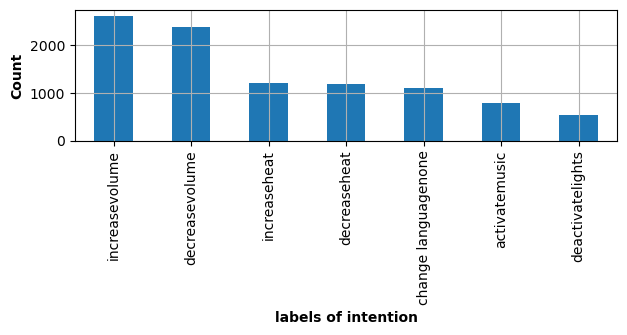

In [31]:
ax = train_df['intention'].value_counts().plot(kind='bar', colormap = 'tab10', figsize=(7,1.7))
plt.xlabel("labels of intention",fontweight = 'bold')
plt.ylabel("Count",fontweight = 'bold')
plt.grid()
plt.show()

### Extract MFFCs


#### This code get duration of all data then trim audios and pad all data to (10.5 (s)). Finally extract MFFCs from them.

In [ ]:
# DBT=[]
# mfccs= []
# for i in range(0, 9854):
#     path=(audiopath[i])
#     x,sr= librosa.load(path)
#     Duration_Before_Trim= librosa.get_duration(filename=path)
#     trim=librosa.effects.trim(x,top_db=20)
#     o=231525-len(trim[0])
#     paddig=np.pad(trim[0],(0,o))
#     q= librosa.feature.mfcc(y=paddig, sr=sr)
#     DBT.append(Duration_Before_Trim)
#     mfccs.append(q)

c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20872\483257721.py:6: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in vers

In [4]:
DBT = []
mfccs = []
target_length = 231525  # 10.5 seconds in samples (assuming 22050 Hz sample rate)
top_db = 20  # dB threshold for trimming

for path in tqdm(audiopath, desc="Processing Audio"):
    # Load audio (retain original sample rate)
    x, sr = librosa.load(path, sr=None)

    # Get duration (avoid redundant file reading)
    duration_before_trim = len(x) / sr

    # Trim silence
    trimmed_audio, _ = librosa.effects.trim(x, top_db=top_db)

    # Pad or truncate to the target length
    processed_audio = librosa.util.fix_length(trimmed_audio, size=target_length)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=processed_audio, sr=sr)

    # Store results
    DBT.append(duration_before_trim)
    mfccs.append(mfcc)

Processing Audio:   0%|          | 0/9854 [00:00<?, ?it/s]c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
Processing Audio: 100%|██████████| 9854/9854 [02:32<00:00, 64.74it/s]


# Visualizations

c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


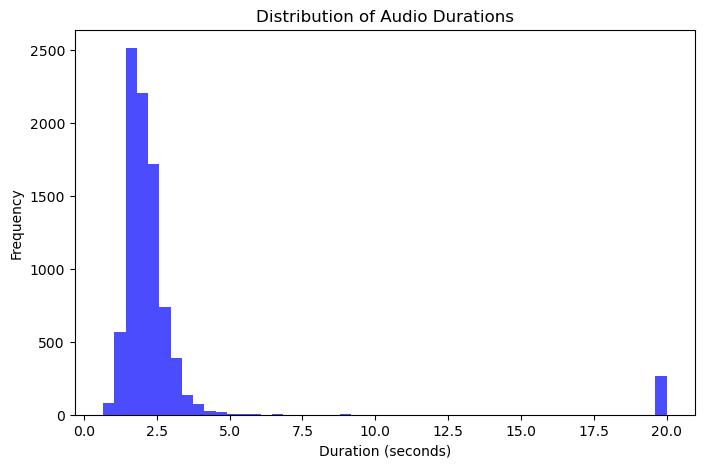

Lower Bound: 0.6444062500000001, Upper Bound: 3.4771562499999997
Removed 504 outliers.


In [ ]:
# # Define function to get audio duration
# def get_audio_duration(file_path):
#     try:
#         y, sr = librosa.load(file_path, sr=None)
#         return librosa.get_duration(y=y, sr=sr)  # Get duration
#     except:
#         return None  # Return None for problematic files

# # Apply function to all audio file paths
# train_df["duration"] = train_df["path"].apply(get_audio_duration)

# # Visualize duration distribution
# plt.figure(figsize=(8, 5))
# plt.hist(train_df["duration"], bins=50, color="blue", alpha=0.7)
# plt.xlabel("Duration (seconds)")
# plt.ylabel("Frequency")
# plt.title("Distribution of Audio Durations")
# plt.show()

# # Remove Outliers (Using IQR Method)
# Q1 = train_df["duration"].quantile(0.25)
# Q3 = train_df["duration"].quantile(0.75)
# IQR = Q3 - Q1

# # Define lower and upper bounds
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

# # Filter out extreme durations
# train_clean = train_df[(train_df["duration"] >= lower_bound) & (train_df["duration"] <= upper_bound)]

# # Display how many audios were removed
# print(f"Removed {len(train_df) - len(train_clean)} outliers.")

In [ ]:
# # Parameters
# N_MFCC = 13
# SAMPLE_RATE = 16000
# FIXED_DURATION = 3.0
# FIXED_LENGTH = int(FIXED_DURATION * SAMPLE_RATE)

# # Storage for features and labels
# X = []
# # y = []

# for idx, row in tqdm(train_clean.iterrows(), total=len(train_clean), desc="Extracting MFCCs"):
#     try:
#         # Load audio
#         y_audio, sr = librosa.load(row["path"], sr=SAMPLE_RATE)

#         # Pad or trim
#         y_audio = librosa.util.fix_length(y_audio, size=FIXED_LENGTH)

#         # Extract MFCCs
#         mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=N_MFCC)

#         # Transpose to shape (time, features)
#         mfcc = mfcc.T  # Shape: (time_steps, n_mfcc)

#         # Store
#         X.append(mfcc)
#         # y.append(row["intention"])

#     except Exception as e:
#         print(f"Error with {row['path']}: {e}")

Extracting MFCCs: 100%|██████████| 8237/8237 [00:42<00:00, 195.04it/s]


In [ ]:
# # 1. Flatten MFCCs
# X_flat = np.array([x.flatten() for x in X])
# y = train_clean['intention']

# # # 2. Encode labels
# # le = LabelEncoder()
# # y_encoded = le.fit_transform(y)

# X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=4, stratify=y)

# # 3. Apply SMOTE
# smote = SMOTE(random_state=4)
# smote = SMOTE(random_state=4, sampling_strategy='not majority')
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [16]:
feature= np.array(mfccs)
feature= feature.reshape(feature.shape[0], -1)

In [17]:
x= feature
y= train_df['intention']

In [18]:
# split dataset to 80%(train)/20%(test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4, stratify=y)

In [19]:
smote = SMOTE(random_state=4, sampling_strategy='not majority')

X_train, Y_train = smote.fit_resample(x_train,y_train)

In [20]:
#data after oversampling, now it's balance
Y_train.value_counts()

intention
change languagenone    2091
decreasevolume         2091
decreaseheat           2091
deactivatelights       2091
increaseheat           2091
increasevolume         2091
activatemusic          2091
Name: count, dtype: int64

In [ ]:
# model = LogisticRegression(C=1, solver="liblinear", max_iter=1000)
# model.fit(X_train, Y_train)

# y_pred = model.predict(X_test)

# accuracy_score(y_test, y_pred) * 100

In [21]:
LGBM= lightgbm.LGBMClassifier(random_state=4, n_estimators=2000, num_leaves=70, learning_rate=0.05)
LGBM.fit(X_train, Y_train)
#preds_train = LGBM.predict(x_train)
y_pred = LGBM.predict(x_test)
print('Accuracy', round(accuracy_score(y_test, y_pred), 5), '\n')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.248982 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 465718
[LightGBM] [Info] Number of data points in the train set: 14637, number of used features: 2481
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

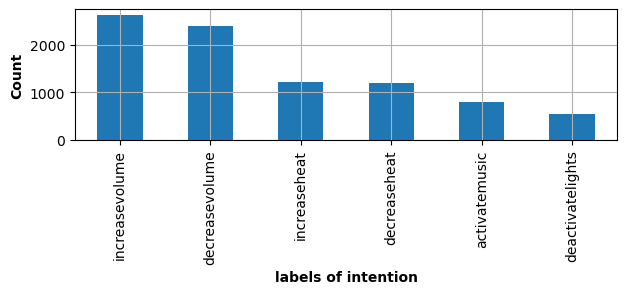

In [ ]:
# ax = df['intention'].value_counts().plot(kind='bar', colormap = 'tab10', figsize=(7,1.7))
# plt.xlabel("labels of intention",fontweight = 'bold')
# plt.ylabel("Count",fontweight = 'bold')
# plt.grid()
# plt.show()

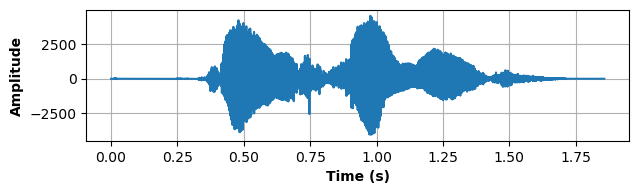

In [ ]:
# wavfile= audiopath[0]
# a, b= wf.read(wavfile)

# duration= len(b)/a 
# c= np.linspace(0,duration,len(b))
# plt.figure(figsize=(7,1.7))
# plt.plot(c,b)
# plt.grid()
# plt.xlabel('Time (s)', fontweight = 'bold')
# plt.ylabel('Amplitude', fontweight = 'bold')
# plt.show()

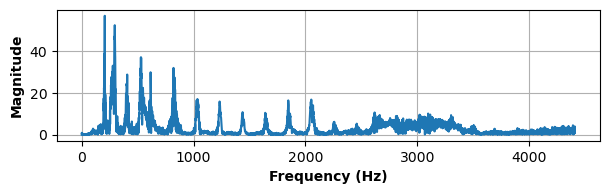

In [ ]:
# k,sr= librosa.load(audiopath[0])

# a = np.fft.fft(k)
# a_mag = np.absolute(a)
# plt.figure(figsize=(7,1.7))
# b = np.linspace(0, sr, len(a_mag))
# b_bins = int(len(a_mag)*0.2)  
# plt.plot(b[:b_bins], a_mag[:b_bins])
# plt.ylabel('Magnitude', fontweight = 'bold')
# plt.xlabel('Frequency (Hz)', fontweight = 'bold')
# plt.grid()
# plt.show()

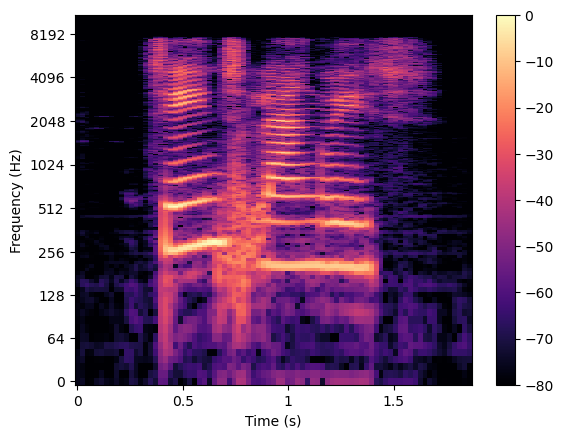

<Figure size 500x400 with 0 Axes>

In [ ]:
# k, sr= librosa.load(audiopath[0])
# a= librosa.stft(k)
# b= librosa.amplitude_to_db(np.abs(a), ref=np.max)

# fig, ax= plt.subplots()
# pic= librosa.display.specshow(b, x_axis='time', y_axis='log', ax=ax)
# ax.set(ylabel='Frequency (Hz)', xlabel='Time (s)')
# fig.colorbar(pic, ax=ax)
# plt.figure(figsize=(5,4))
# plt.show()

# Train Data

In [24]:
feature= np.array(mfccs)
feature= feature.reshape(feature.shape[0], -1)

In [25]:
x= feature
y= df['intention']

In [26]:
#split dataset to 80%(train)/20%(test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

ValueError: Found input variables with inconsistent numbers of samples: [9854, 8741]

### SMOTE Oversampling

In [35]:
smote = SMOTE(random_state=4, sampling_strategy='not majority')

X_train, Y_train = smote.fit_resample(x,y)

In [21]:
#data after oversampling, now it's balance
Y_train.value_counts()

change languagenone    2614
activatemusic          2614
deactivatelights       2614
increasevolume         2614
decreasevolume         2614
increaseheat           2614
decreaseheat           2614
Name: intention, dtype: int64

# Classification Models

In [ ]:
#tunning random forest with grid search

#x = X_train
#y = Y_train
#RF= RandomForestClassifier()
#param= {'criterion':['gini', 'entropy'], 'max_depth':[None,5,10], 'n_estimators':[50,100,200,2000]}
#GS= GridSearchCV(RF, param)
#%time GS.fit(x,y)
#GS.best_score_
#GS.best_params_

In [22]:
#final Random Forest Model

#x_train = X_train
#y_train = Y_train
#RF = RandomForestClassifier(n_estimators=2000, criterion='entropy', max_depth=None, random_state=4)
#RF.fit(x_train, y_train)
#preds_train = RF.predict(x_train)
#preds_test = RF.predict(x_test)
#print('Accuracy', round(accuracy_score(y_test, preds_test), 5), '\n')

RandomForestClassifier(criterion='entropy', n_estimators=2000, random_state=4)

In [ ]:
#tunning lightGBM with grid search

#x = X_train
#y = Y_train
#LGBM= lightgbm.LGBMClassifier()
#param= {'num_leaves':[25,50,70], 'learning_rate':[0.01,0.05,0.1], 'n_estimators':[100,1000,2000]}
#GS= GridSearchCV(LGBM, param)
#%time GS.fit(x,y)
#GS.best_score_
#GS.best_params_

In [ ]:
#final LGBM Model

# x_train = X_train
# y_train = Y_train
# LGBM= lightgbm.LGBMClassifier(random_state=4, n_estimators=2000, num_leaves=70, learning_rate=0.05)
# LGBM.fit(x_train, y_train)
#preds_train = LGBM.predict(x_train)
#preds_test = LGBM.predict(x_test)
#print('Accuracy', round(accuracy_score(y_test, preds_test), 5), '\n')

LGBMClassifier(learning_rate=0.05, n_estimators=2000, num_leaves=70,
               random_state=4)

# Test Data

In [22]:
df_test = pd.read_csv('evaluation.csv')
df_test['path'] = 'D:/Data Science and Engineering/Datasets/' + df_test['path']
audiopath_test = df_test['path'].tolist()

audiopath_test[:5]

['D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/NgQEvO2x7Vh3xy2xz/f53ce6b0-45bf-11e9-8ec0-7bf21d1cfe30.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/k5bqyxx2lzIbrlg9/1d5f80b0-4527-11e9-a843-8db76f4b5e29.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/7B4XmNppyrCK977p/1c0d59c0-45cd-11e9-9992-dfba019cb646.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/k5bqyxx2lzIbrlg9/275c3960-4526-11e9-a843-8db76f4b5e29.wav',
 'D:/Data Science and Engineering/Datasets/dsl_data/audio/speakers/V4ZbwLm9G5irobWn/b7c7a180-4529-11e9-a843-8db76f4b5e29.wav']

In [38]:
mfccs_test= []
for i in range(0, 1455):
    x_test,sr= librosa.load(audiotestpath[i])
    trim_test=librosa.effects.trim(x_test,top_db=20)
    o_test=231525-len(trim_test[0])
    paddig_test=np.pad(trim_test[0],(0,o_test))
    q_test= librosa.feature.mfcc(y=paddig_test, sr=sr)
    mfccs_test.append(q_test)

In [23]:
DBT_test = []
mfccs_test = []
target_length = 231525  # 10.5 seconds in samples (assuming 22050 Hz sample rate)
top_db = 20  # dB threshold for trimming

for path in tqdm(audiopath_test, desc="Processing Audio"):
    # Load audio (retain original sample rate)
    x, sr = librosa.load(path, sr=None)

    # Get duration (avoid redundant file reading)
    duration_before_trim = len(x) / sr

    # Trim silence
    trimmed_audio, _ = librosa.effects.trim(x, top_db=top_db)

    # Pad or truncate to the target length
    processed_audio = librosa.util.fix_length(trimmed_audio, size=target_length)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=processed_audio, sr=sr)

    # Store results
    DBT_test.append(duration_before_trim)
    mfccs_test.append(mfcc)

Processing Audio: 100%|██████████| 1455/1455 [00:34<00:00, 42.36it/s]


In [39]:
feature_test= np.array(mfccs_test)
feature_test= feature_test.reshape(feature_test.shape[0], -1)

In [ ]:
x_valid = feature_test
y_predict = LGBM.predict(x_valid)